# Test Plant Diseases detection App

In [5]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


## Importing Libraries

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## Getting Class names from the Validation Set

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17452 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

## Loading Model

In [13]:
cnn = tf.keras.models.load_model('trained_plant_disease_model.keras')

C:\Users\HP\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Visualising and Performing Prediction on Single image

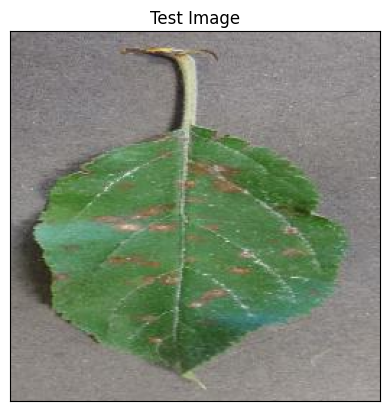

In [23]:
#Test Image Visualization
import cv2
image_path = 'test/AppleCedarRust2.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [24]:
from tensorflow.keras.preprocessing import image

## Image Processing on Test Image

In [25]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
input_arr.shape

(1, 128, 128, 3)

In [26]:
predictions = cnn.predict(input_arr)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
[[2.01777020e-03 3.24924918e-06 9.56972778e-01 4.88573232e-06
  4.96119128e-07 1.38855205e-04 1.37966580e-08 7.63040152e-05
  7.36408310e-06 4.49115350e-06 5.30026578e-10 5.78201492e-04
  9.19906233e-05 4.86985264e-05 8.57268478e-09 3.81432379e-08
  6.37615682e-04 7.45780611e-08 9.84928105e-04 4.20301649e-06
  1.12459406e-06 4.41032098e-05 1.00174766e-08 6.07586389e-06
  1.38799972e-10 7.50173456e-07 6.33095508e-04 4.44574380e-06
  4.92117181e-03 1.74276587e-02 4.00582980e-03 1.86858655e-04
  1.11956755e-02 1.46363408e-10 1.28279112e-07 7.27038767e-08
  6.33191462e-07 4.66338747e-07]]


In [27]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

2


## Displaying the disease prediction


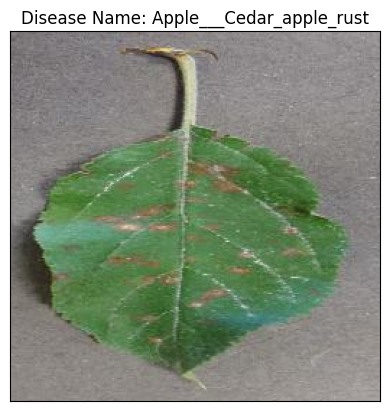

In [28]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()